In [10]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.animation as animation


In [11]:
def add_person(name, tree):
  global next_id
  this_id = next_id
  tree[this_id] = {
    "name": name,
    "children": [],
    "parents": [],
    "spouse": []}
  next_id += 1
  return this_id




def add_parent_child(parent_id, child_id, tree):
  tree[parent_id]["children"].append(child_id)
  tree[child_id]["parents"].append(parent_id)


def add_spouse(spouse_one_id, spouse_two_id, tree):
  tree[spouse_one_id]["spouse"].append(spouse_two_id)
  tree[spouse_two_id]["spouse"].append(spouse_one_id)

def get_neighbors(person_id, mode, tree):
  if mode == 'all':
    return tree[person_id]['children'] + tree[person_id]['spouse'] + tree[person_id]['parents']
  elif mode == 'children':
    return tree[person_id]['children']






In [12]:
from collections import deque
def bfs(tree, start_node, mode):

  queue = deque([start_node])
  best_neighbor = {

  }
  best_neighbor[start_node] = None #mark start node already as visited so we don't visit it again during while loopS


  while queue:
    current_node = queue.popleft()

    for neighbor in get_neighbors(current_node, mode, tree):
      if neighbor not in best_neighbor.keys():
        queue.append(neighbor)
        best_neighbor[neighbor] = current_node #current node is the best neighbor
  return best_neighbor










In [13]:
def get_path(start_node, end_node, neighbor_dict):
  #assumes that bfs did succeed in finding a path from start node to end node
  path_look_up = []
  while True:
    if end_node == None:
      break
    path_look_up.append(end_node)
    end_node = neighbor_dict[end_node]
  path_look_up.reverse()
  return path_look_up





In [14]:
tree = {}
next_id = 0

son = add_person("son", tree)
daughter = add_person("daughter", tree)
mom = add_person("Mom", tree)
dad   = add_person("Dad", tree)
nana  = add_person("Grandma", tree)
nani  = add_person("Grandpa", tree)
dadi = add_person("Grandma", tree)
dadaji = add_person("Grandpa", tree)






add_spouse(dad, mom, tree)
add_parent_child(dad, son, tree)
add_parent_child(mom, son, tree)
add_parent_child(dad, daughter, tree)
add_parent_child(mom, daughter, tree)
add_spouse(nana, nani, tree)
add_spouse(dadi, dadaji, tree)
add_parent_child(nana, mom, tree)
add_parent_child(nani, mom, tree)
add_parent_child(dadaji, dad, tree)
add_parent_child(dadi, dad, tree)

In [15]:
memo = {

}
def compute_generation(person_id, tree, memo):
  if person_id in memo.keys(): #look up
    return memo[person_id]
  elif (not tree[person_id]['parents']) and (not tree[person_id]['spouse']): #no parents + no spouse
    return 0
    #no parents + #spouse has no parents
  elif (not tree[person_id]['parents']) and all(not(tree[spouse_id]['parents']) for spouse_id in tree[person_id]['spouse']):
    return 0
    #recurse/look up on parents generation
  elif tree[person_id]['parents']:
    memo[person_id] = 1 + max(compute_generation(parent_id, tree, memo) for parent_id in tree[person_id]['parents'])
    #recurse/look up on spouse
  elif tree[person_id]['spouse']:
     memo[person_id] = max(compute_generation(spouse_id, tree, memo) for spouse_id in tree[person_id]['spouse'])
  return memo[person_id]







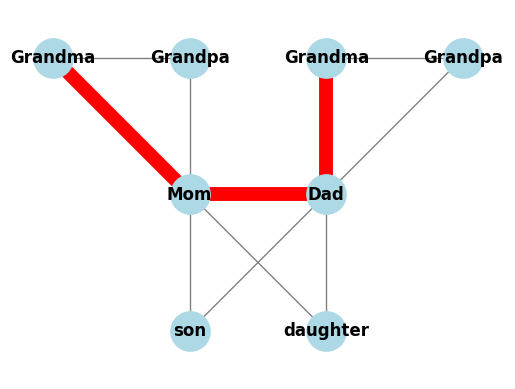

In [16]:
def create_hierchal_map(tree, memo, start_node=None, end_node=None):
  G = nx.Graph()
  for key in tree.keys():
    G.add_node(key, layer=compute_generation(key, tree, memo))
  for key, value in tree.items():
    for parent in value['parents']:
      G.add_edge(parent, key)
  for key, value in tree.items():
    for spouse in value['spouse']:
      G.add_edge(spouse, key)
  pos = nx.multipartite_layout(G, subset_key="layer", align="horizontal")
  labels = {}
  for node in G.nodes():
    labels[node] = tree[node]['name']
  flipped_pos = {}
  for node, value in pos.items():
    flipped_pos[node] = [value[0], -1*value[1]]
  plt.axis('equal')
  nx.draw(G, flipped_pos, labels=labels, node_color='lightblue',
        edge_color='gray', node_size=800, font_weight='bold')
  if start_node is not None and end_node is not None:
    result_bfs = bfs(tree, start_node, 'all')
    compute_path = get_path(start_node, end_node, result_bfs)
    path_edges = list(zip(compute_path,compute_path[1:]))
    nx.draw_networkx_edges(G,flipped_pos,edgelist=path_edges,edge_color='r',width=10)
  plt.show()





create_hierchal_map(tree, memo, 4, 6)

In [17]:
'''
from collections import deque
def bfs(tree, start_node):

  queue = deque([start_node])
  best_neighbor = {

  }
  best_neighbor[start_node] = None #mark start node already as visited so we don't visit it again during while loopS


  while queue:
    current_node = queue.popleft()

    for neighbor in tree[current_node]:
      if neighbor not in best_neighbor.keys():
        queue.append(neighbor)
        best_neighbor[neighbor] = current_node #current node is the best neighbor
  return best_neighbor

def recursive_distance_calculation(start_node, end_node, neighbor_dict):
  #assumes that bfs did succeed in finding a path from start node to end node
  if start_node == end_node:
    return 0
  if neighbor_dict[end_node] == start_node:
    return 1
  else:
    return 1 + recursive_distance_calculation(start_node, neighbor_dict[end_node], neighbor_dict)


print(recursive_distance_calculation('s', 'd', value))

def get_path(start_node, end_node, neighbor_dict):
  #assumes that bfs did succeed in finding a path from start node to end node
  path_look_up = []
  while True:
    if end_node == None:
      break
    path_look_up.append(end_node)
    end_node = neighbor_dict[end_node]
  path_look_up.reverse()
  return path_look_up


print(get_path('s', 'd', value))

'''






"\nfrom collections import deque\ndef bfs(tree, start_node):\n\n  queue = deque([start_node])\n  best_neighbor = {\n\n  }\n  best_neighbor[start_node] = None #mark start node already as visited so we don't visit it again during while loopS\n\n\n  while queue:\n    current_node = queue.popleft()\n\n    for neighbor in tree[current_node]:\n      if neighbor not in best_neighbor.keys():\n        queue.append(neighbor)\n        best_neighbor[neighbor] = current_node #current node is the best neighbor\n  return best_neighbor\n\ndef recursive_distance_calculation(start_node, end_node, neighbor_dict):\n  #assumes that bfs did succeed in finding a path from start node to end node\n  if start_node == end_node:\n    return 0\n  if neighbor_dict[end_node] == start_node:\n    return 1\n  else:\n    return 1 + recursive_distance_calculation(start_node, neighbor_dict[end_node], neighbor_dict)\n\n\nprint(recursive_distance_calculation('s', 'd', value))\n\ndef get_path(start_node, end_node, neighbor_d